In [1]:
import numpy as np 
import sys
import pandas as pd
import datetime as datetime    
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates 
import matplotlib as mpl
import re 
from scipy import signal #for filtering
import cmocean
import matplotlib.dates as mdates
print("Modules imported")

Modules imported


In [2]:
import re 
file="/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_28/station.in"
station_id =[]
with open(file) as f:
    f.readline()
    for station in range(int(f.readline())):
        line = f.readline()
        if '!' in line:
            station_id.append(line.split('!')[-1])
        else:
            station_id.append(None)
# print(station_id)

print(len(station_id))

stations = []
for sublist in station_id:
    match = re.search(r'"(.*?)"', sublist)
    if match:
        stations.append(match.group(1).strip())
    else :
        stations.append(sublist.replace("\n", "").strip())
print(len(set(stations)))


for i, station in enumerate(stations):
    print("%d == %s" % (i+1,station))

408
379
1 == San Joaquin at Antioch
2 == Mokelumne River at Benson's Ferry
3 == Cache Slough
4 == Cache Creek at Yolo
5 == Old River at Coney Island
6 == Clifton Court
7 == Discovery Bay at Indian Slough
8 == Doughty Cut above Grant Line Canal
9 == Sacramento River at Emmaton
10 == Sacramento River at Emmaton
11 == emm upper Emmaton
12 == emm lower Emmaton
13 == Farrar Park
14 == Grant Line Canal at Tracy Rd Bridge
15 == Green's Landing
16 == Harvey O Banks PP
17 == Holland Tract
18 == Harvey O Banks PP
19 == CCWD Old River near Discovery Bay
20 == CCWD Rock Slough PP
21 == Italian Slough Headwater near Byron
22 == Jersey Point
23 == Sacramento River at Mallard Island
24 == Sacramento River at Mallard Island
25 == Middle River at Howard Rd Bridge
26 == San Joaquin at Mossdale Bridge
27 == Middle River at Tracy Blvd
28 == Old River Barrier near DMC (Above)
29 == Old River below Dam
30 == Old River at Bacon Island
31 == Old River at Head
32 == Old River at Byron
33 == Prisoners Point
34 

In [3]:
file27='/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_27/station_files/run_27_salinity_padded_filt.csv'
file28='/expanse/lustre/scratch/jisrael/temp_project/run_schism/savio_output/run_31DCP/staout_6_filt.csv'
file29='/expanse/lustre/scratch/jisrael/temp_project/run_schism/savio_output/run_30cor/staout_6_filt.csv'

In [4]:
#load the filtered station data
dtformat = '%Y-%m-%d %H:%M:%S'
run27=pd.read_csv(file27)
run27['datetime']=pd.to_datetime(run27['time'],format=dtformat)
run27.set_index("datetime",inplace=True)
run28=pd.read_csv(file28)
run28['datetime']=pd.to_datetime(run28['time'],format=dtformat)
run28.set_index("datetime",inplace=True)
run29=pd.read_csv(file29)
run29['datetime']=pd.to_datetime(run29['time'],format=dtformat)
run29.set_index("datetime",inplace=True)

/scratch/jisrael/job_54651387/ipykernel_1979186/1785802375.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  run27['datetime']=pd.to_datetime(run27['time'],format=dtformat)
/scratch/jisrael/job_54651387/ipykernel_1979186/1785802375.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  run28['datetime']=pd.to_datetime(run28['time'],format=dtformat)
/scratch/jisrael/job_54651387/ipykernel_1979186/1785802375.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, 

NameError: name 'file30' is not defined

# compute salinity-days as the sum of salinity in PSU over the compliance level 

In [29]:
station_indices=[23,9,22,203,105,60]
# fig, ax = plt.subplots(3,2,figsize=(20,10),sharex=True,layout='constrained',label='compliance')
# mpl.rcParams.update({'font.size': 22})
# # ax.grid(alpha=0.5)
sdate=pd.to_datetime("2018-10-1")
edate=pd.to_datetime("2021-10-1")
years=np.unique(run27[sdate:edate].index.year.values)
wymonths=np.arange((len(years)-1)*12) # months in 3 water years hard coded for now 
#months=np.arange(0,36) #np.unique(run27[sdate:edate].index.month.values)
samplesperday=60*24/15 # every 15 min
daysabovec_1=np.empty(wymonths.shape)
daysabovec_2=np.empty(wymonths.shape)
daysabovec_3=np.empty(wymonths.shape)
for idx in station_indices:
    if idx == 23:
        s=(0,0)
        tstring='Chipps Island'
        c=1.36
        m2d = [1,7,8,9,10,11,12]
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2019-2-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
    if idx == 9:
        s=(0,1)
        tstring='Emmaton'
        c=0.492
        m2d = [1,2,3,9,10,11,12]
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 22:
        s=(1,0)
        tstring='Jersey Point'
        c=0.492
        m2d = [1,2,3,9,10,11,12]
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 203:
        s=(1,1)
        tstring='Franks Tract'
        c=0
        m2d = np.arange(1,13)
    if idx == 105:
        s=(2,0)
        tstring='CCWD'
        c=0.315
        m2d = []
        #ax[s].hlines(y=0.3255, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    if idx == 60:
        s=(2,1)
        tstring='CCFB'
        c=0.328
        m2d = []
        #ax[s].hlines(y=0.3387, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    
    print(tstring)
    # subtract the compliance level to get the amount of salinity above compliance
    values1 = run27[str(idx)][sdate:edate]-c
    values2 = run28[str(idx)][sdate:edate]-c
    values3 = run29[str(idx)][sdate:edate]-c
    # mask out the days that are under compliance
    comp1=values1.where(values1>0,0)
    comp2=values2.where(values2>0,0)
    comp3=values3.where(values3>0,0)

    # print('baseline has '+str(len(comp1.dropna())/samplesperday)+' days above compliance')
    # print('dcp has '+str(len(comp2.dropna())/samplesperday)+' days above compliance')
    # print('cor has '+str(len(comp3.dropna())/samplesperday)+' days above compliance')

    #how many salinity- days above compliance for each month
    
    # make a df to write to csv
    stadays1=np.array([])
    stadays2=np.array([])
    stadays3=np.array([])

    # now that we have multiple years this is not going to work, overwriting data
    for y in years:
        #just look at one year
        print(y)
        comp1_y=comp1.where(comp1.index.year==y)
        comp2_y=comp2.where(comp2.index.year==y)
        comp3_y=comp3.where(comp3.index.year==y)
        #to get the unique months including those that are never out of compliance need to use a different df 
        #choose a month from this year
        my= np.unique(values1.where(values1.index.year==y).dropna().index.month.values)
        #print(my)
        for m in my:
            #print(m)
            if m in m2d:
                days1 = np.nan
                days2 = np.nan
                days3 = np.nan
            else:
                # take the sum for this month
                days1=comp1_y[comp1_y.index.month==m].dropna().sum()/samplesperday
                days2=comp2_y[comp2_y.index.month==m].dropna().sum()/samplesperday
                days3=comp3_y[comp3_y.index.month==m].dropna().sum()/samplesperday
                print('mean exceedance is '+ str(comp1_y[comp1_y.index.month==m].dropna().mean()) + ' psu for the '+str(m) +' month')
            
            stadays1=np.append(stadays1,days1)
            stadays2=np.append(stadays2,days2)
            stadays3=np.append(stadays3,days3)

    #after going though all the stations stack this array with the others
    daysabovec_1=np.vstack((daysabovec_1,stadays1))
    daysabovec_2=np.vstack((daysabovec_2,stadays2))
    daysabovec_3=np.vstack((daysabovec_3,stadays3))
    #print(daysabovec)
    
    

Chipps Island
2018
2019
mean exceedance is 0.0 psu for the 2 month
mean exceedance is 0.0 psu for the 3 month
mean exceedance is 0.0 psu for the 4 month
mean exceedance is 0.0 psu for the 5 month
mean exceedance is 0.0 psu for the 6 month
2020
mean exceedance is 0.9918234934605028 psu for the 2 month
mean exceedance is 1.7718101504835018 psu for the 3 month
mean exceedance is 1.0572410707583133 psu for the 4 month
mean exceedance is 2.1250151285662424 psu for the 5 month
mean exceedance is 2.5302200546938667 psu for the 6 month
2021
mean exceedance is 2.446418153532341 psu for the 2 month
mean exceedance is 2.9199088350809497 psu for the 3 month
mean exceedance is 3.674462408577401 psu for the 4 month
mean exceedance is 6.014738176761135 psu for the 5 month
mean exceedance is 7.4922049856791775 psu for the 6 month
Emmaton
2018
2019
mean exceedance is 0.0 psu for the 4 month
mean exceedance is 0.0 psu for the 5 month
mean exceedance is 0.0 psu for the 6 month
mean exceedance is 0.0 psu 

In [26]:
daysabovec_1

array([[0.00000000e+000, 4.94065646e-324, 9.88131292e-324,
        1.48219694e-323, 1.97626258e-323, 2.47032823e-323,
        2.96439388e-323, 3.45845952e-323, 3.95252517e-323,
        4.44659081e-323, 4.94065646e-323, 5.43472210e-323,
        5.92878775e-323, 6.42285340e-323, 6.91691904e-323,
        7.41098469e-323, 7.90505033e-323, 8.39911598e-323,
        8.89318163e-323, 9.38724727e-323, 9.88131292e-323,
        1.03753786e-322, 1.08694442e-322, 1.13635099e-322,
        1.18575755e-322, 1.23516411e-322, 1.28457068e-322,
        1.33397724e-322, 1.38338381e-322, 1.43279037e-322,
        1.48219694e-322, 1.53160350e-322, 1.58101007e-322,
        1.63041663e-322, 1.67982320e-322, 1.72922976e-322],
       [            nan,             nan,             nan,
                    nan, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
                    nan,             nan,             nan,
                    nan,             nan,             n

In [28]:
df_sdays1=pd.DataFrame(data=daysabovec_1[1:,:],columns=wymonths)
df_sdays2=pd.DataFrame(data=daysabovec_2[1:,:],columns=wymonths)
df_sdays3=pd.DataFrame(data=daysabovec_3[1:,:],columns=wymonths)
df_sdays1

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,...,NaN,NaN,68.499708,90.517174,110.233872,186.456883,224.766150,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,2.712752,29.543663,55.968863,58.357939,51.143480,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.000000,4.631491,15.644595,15.515613,11.816352,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.721227,0.297069,0.330465,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.227497,2.425054,1.440226,0.000000,0.000000,0.000000,1.747325,2.918671,1.818389,1.374612
5,0.510622,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.155149,0.224504,0.340890,0.182086,0.130025,0.000000,0.000000,0.038782,0.058929,0.002993


<Axes: >

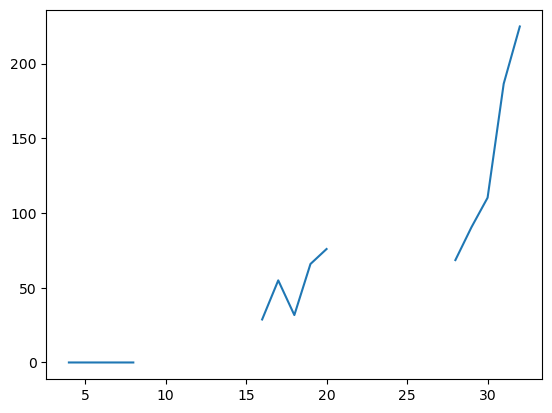

In [36]:
df_sdays1.iloc[0,:].plot()

In [37]:
df_sdays1.to_csv('./salinity_days_by_month_2026_10_04_baseline.csv',index=False)
df_sdays2.to_csv('./salinity_days_by_month_2026_10_04_dcp.csv',index=False)
df_sdays3.to_csv('./salinity_days_by_month_2026_10_04_cor.csv',index=False)
